In [1]:
%pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


/home/lyly/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/lyly/.cache/kagglehub/datasets/spscientist/students-performance-in-exams/versions/1


In [2]:
import os
print(os.listdir(path))

['StudentsPerformance.csv']


In [3]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "StudentsPerformance.csv"))
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Étape 1 — Exploration initiale du dataset

In [5]:
df.info()
df.describe()
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [6]:
df.columns = df.columns.str.replace(' ', '_')
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


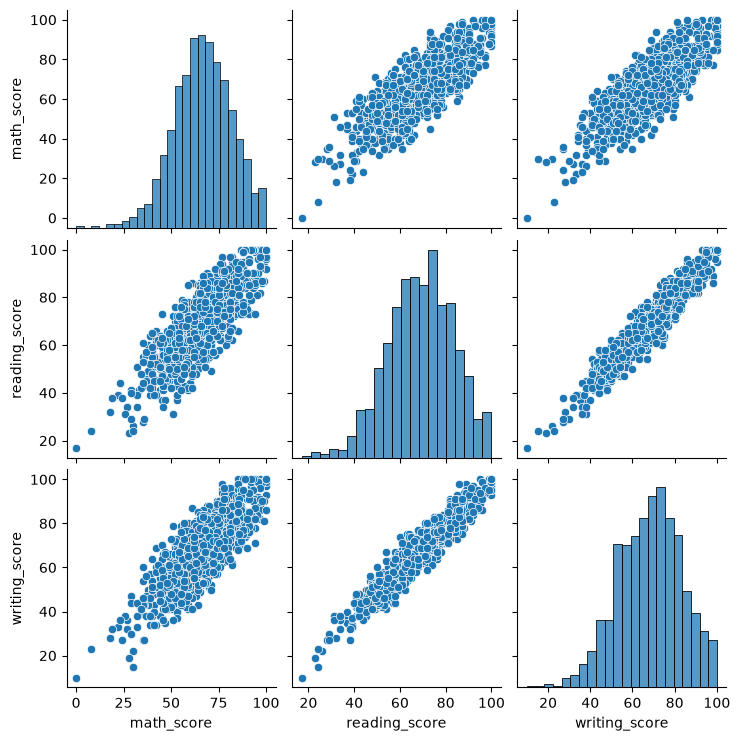

In [7]:
%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['math_score', 'reading_score', 'writing_score']])
plt.show()

In [8]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
from scipy.stats import pearsonr

r, p = pearsonr(df['math_score'], df['reading_score'])
print(f"r = {r:.3f}, p-value = {p:.5f}")

r = 0.818, p-value = 0.00000


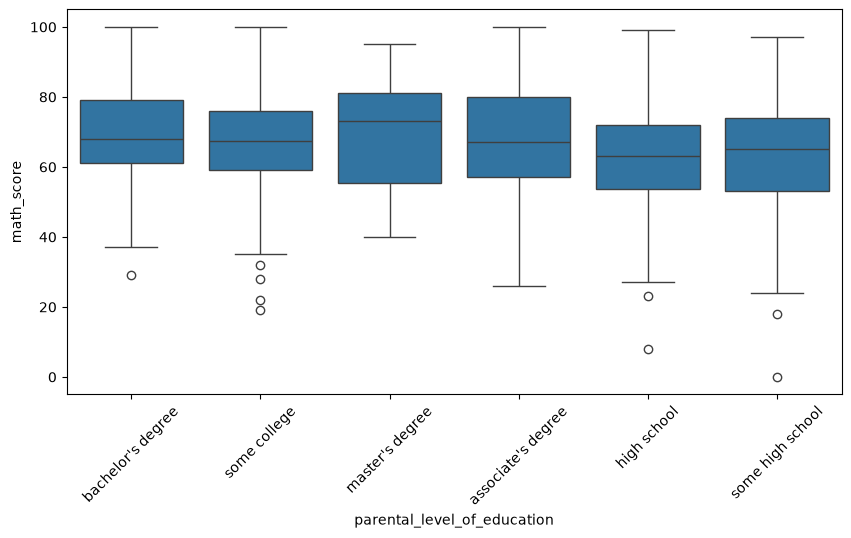

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='parental_level_of_education', y='math_score')
plt.xticks(rotation=45)
plt.show()

In [11]:
ordre = ["some high school", "high school", "some college", 
         "associate's degree", "bachelor's degree", "master's degree"]
df['parent_edu_num'] = df['parental_level_of_education'].apply(lambda x: ordre.index(x))

from scipy.stats import spearmanr
rho, p = spearmanr(df['parent_edu_num'], df['math_score'])
print(f"rho = {rho:.3f}, p-value = {p:.5f}")

rho = 0.144, p-value = 0.00000


In [12]:
r2, p2 = pearsonr(df['reading_score'], df['writing_score'])
r3, p3 = pearsonr(df['math_score'], df['writing_score'])
print(f"reading/writing: r = {r2:.3f}, p-value = {p2:.5f}")
print(f"math/writing: r = {r3:.3f}, p-value = {p3:.5f}")

reading/writing: r = 0.955, p-value = 0.00000
math/writing: r = 0.803, p-value = 0.00000


In [13]:
df['score_langage'] = (df['reading_score'] + df['writing_score']) / 2
df[['reading_score', 'writing_score', 'score_langage']].head()

,reading_score,writing_score,score_langage
0,72,74,73.0
1,90,88,89.0
2,95,93,94.0
3,57,44,50.5
4,78,75,76.5


In [14]:
r, p = pearsonr(df['score_langage'], df['math_score'])
print(f"score_langage vs math_score: r = {r:.3f}, p-value = {p:.5f}")

score_langage vs math_score: r = 0.819, p-value = 0.00000


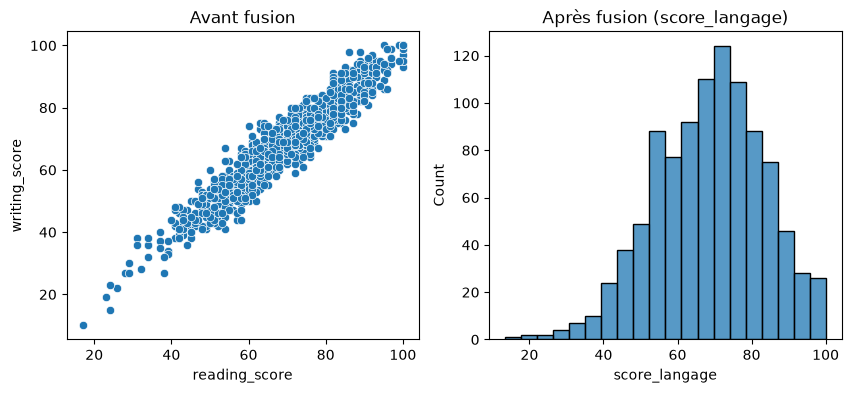

In [15]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='reading_score', y='writing_score')
plt.title('Avant fusion')

plt.subplot(1,2,2)
sns.histplot(df['score_langage'], bins=20)
plt.title('Après fusion (score_langage)')
plt.show()

## Conclusion — Analyse des corrélations sur "Students Performance in Exams"

### Objectif
Identifier les facteurs liés à la réussite scolaire (préparation aux examens, éducation des parents, genre, type de repas) sur un dataset de 1000 élèves.

### Méthode
Visualisation systématique (pairplot, boxplot) avant chaque calcul, pour choisir la méthode de corrélation adaptée à la forme observée plutôt que d'appliquer Pearson par défaut.

### Résultats obtenus

| Paire de variables | Méthode | Résultat | Significatif ? |
|---|---|---|---|
| math_score / reading_score | Pearson | r = 0.818 | oui (p < 0.001) |
| reading_score / writing_score | Pearson | r = 0.955 | oui (p < 0.001) |
| math_score / writing_score | Pearson | r = 0.803 | oui (p < 0.001) |

### Interprétation
- Les trois matières sont fortement corrélées entre elles, cohérent avec l'idée d'une réussite scolaire globale.
- **reading_score** et **writing_score** sont quasi-redondants (r² ≈ 0.91) : ils mesurent en grande partie la même compétence sous-jacente (compétence langagière).
- **math_score** reste distinct des deux autres (r ≈ 0.80-0.82) : la logique/calcul sollicite une compétence différente de la lecture/écriture.
- Les nuages de points étant clairement linéaires (pas de courbe, pas d'outliers majeurs), Pearson était le bon choix pour ces trois paires — pas besoin de Spearman ici.

### Décision prise
Fusion de `reading_score` et `writing_score` en une seule variable `score_langage` (moyenne des deux), pour réduire la redondance/colinéarité tout en gardant l'information utile. La distribution de `score_langage` reste une belle courbe en cloche après fusion, confirmant que la fusion n'a rien cassé.

### Variables finales retenues
- `math_score`
- `score_langage` (remplace reading_score + writing_score)

### Pistes non terminées / à compléter
- [ ] Corrélation Spearman entre `parental_level_of_education` (ordinale) et `math_score`
- [ ] Corrélation point-bisériale entre `gender` et `math_score`
- [ ] Test du χ² entre `test_preparation_course` et `lunch`
- [ ] Heatmap globale finale avec les variables retenues

### Ce que j'en retiens (méthodo)
Une corrélation forte ne dit pas automatiquement "il faut fusionner" — ça dépend si les deux variables mesurent vraiment le même concept (ce qui était le cas ici) ou si elles sont juste liées par un facteur externe. La visualisation avant le calcul reste l'étape la plus importante pour éviter de mal interpréter un chiffre.